# iTRAILS results

Loads the outputs produced by the workflow (`gwf run` in the repository root) and
gives a first look at each analysis: the fitted model parameters, the Viterbi
segmentation of the alignment into gene-tree states, and the posterior state
probabilities along the alignment.

The notebook is executed by the workflow itself once all upstream targets are
done, so it simply discovers whatever analyses exist under `steps/itrails/`
(each analysis has one subfolder per step: `split/`, `optimize/`, `viterbi/`,
`posterior/`, `concat/`).

In [3]:
import vscodenb
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import demesdraw
import msprime
from pprint import pprint
from functools import partial
from IPython.display import display, SVG
import graphviz
import random
import time
from statistics import mean


## Reading / visualizing results

In [4]:
def read_estimates(analysis):

    estimates = []
    path = analysis / 'optimize'
    for best_model in sorted(path.glob('*.best_model.yaml')):
        with open(best_model) as f:
            best = yaml.safe_load(f)
        names = dict(zip(['A', 'B', 'C', 'D'], best['settings']['species_list']))
        names['1'] = names['A'] + '-' + names['B']
        names['2'] = names['1'] + '-' + names['C']
        names['upper'] = names['2'] + '-' + names['D']
        T = 0
        estimates.append(best)
    param_map = {}
    for k, v in sorted(estimates[-1]['optimized_parameters'].items()):        
        if k.startswith('N_'):
            param_map[k] = f"N {'-'.join([names[c] for c in k[2:]])}"
        if k.startswith('t_'):
            T += v
            param_map[k] = f"T {names[k[2:]]}"
        if k == 'r':
            param_map[k] = 'Recomb. rate'

    return estimates, param_map

def print_estimates(analysis):
    estimates, param_map = read_estimates(analysis)
    print(f"{analysis.name}")
    for e in estimates: 
        T = 0
        for k, v in sorted(e['optimized_parameters'].items()):
            k = f"{param_map.get(k, k) +':':<35}"
            v = f"{int(v):>7,}" if v > 1 else f"{v:>7,.2g}"
            print(k + v)

def _get_optim_histories(analysis, window=None):
    path = analysis / 'optimize'
    paths = sorted(path.glob('*.optimization_history.csv'))
    if window is not None:
        paths = [paths[window]]
    df_list = []
    for i, path in enumerate(paths):
        _df = pd.read_csv(path)
        df_list.append(_df.assign(win=i))
        df = pd.concat(df_list)
    return df

def plot_param_fit(analysis, window=None, **kwargs):
    df = _get_optim_histories(analysis, window=window)
    plot_df = df.drop(columns=['time', 'loglik']).melt(id_vars=['win', 'n_eval'])
    g = sns.FacetGrid(plot_df, col="variable", hue='win', sharey=False, aspect=2, height=2, col_wrap=2)
    g.map(sns.lineplot, 'n_eval', 'value', **kwargs)
    g.set_titles(col_template="{col_name}")
    g.despine(left=True, bottom=True)

def plot_loglike(analysis, reldiff=True, ax2color='C2', ax2alpha=0.5, window=None, **kwargs):
    plot_df = _get_optim_histories(analysis, window=window)
    fig, ax = plt.subplots(figsize=(7,3))
    if reldiff:
        ax2kwargs = dict(color=ax2color, alpha=0.5)
        ax2kwargs.update(kwargs)
        ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis
        ax2.grid(False)
        ax2.axhline(0, ls='dotted', color=ax2color, alpha=ax2alpha)
        ax2.set_ylabel('relative difference')  # we already handled the x-label with ax1
        ax2.tick_params(axis='y', color=ax2color)
    for name, df in plot_df.groupby('win'):
        if reldiff:
            ax2.plot(df.n_eval, (df.loglik - df.loglik.shift())/df.loglik, **ax2kwargs)
    ax.plot(df.n_eval, df.loglik, **kwargs)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log likelihood')
    # sns.lineplot(df, x='n_eval', y='loglik', ax=ax)

def plot_convergence(analysis, window=None):
    fig, ax = plt.subplots(figsize=(7,3))
    df = _get_optim_histories(analysis, window=window)
    df = df.drop(columns=['time', 'loglik'])#.melt(id_vars=['win', 'n_eval'])
    df = df.set_index(['win', 'n_eval'])
    df = (df - df.min()) / (df.max() - df.min())
    # df = df - df.groupby('win').iloc[-1]
    df = df - df.groupby('win').apply(lambda df: df.iloc[-1]).mean()
    df = df.reset_index()
    plot_df = df.melt(id_vars=['win', 'n_eval'], var_name='Parameter')
    sns.lineplot(plot_df, x='n_eval', y='value', hue='Parameter', style='win', ax=ax)

    # for name, df in _df.groupby('win'):
    #     df = df.drop(columns=['time', 'loglik'])
    #     df = df.set_index('n_eval')
    #     df = (df - df.min()) / (df.max() - df.min())
    #     df = df - df.iloc[-1]
    #     df = df.reset_index()
    #     plot_df = df.melt(id_vars='n_eval', var_name='Parameter')
    #     sns.lineplot(plot_df, x='n_eval', y='value', hue='Parameter', style='win', ax=ax)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Min-max scaled and shifted')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

def show_demography(d, ax=None):
    colored = []
    props = ['tspaint_ghost', 'tspaint_reference']
    for p in d.populations:
        if any(p.extra_metadata.get(prop, False) for prop in props):
            colored.append(p.name)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7,6))
    ax.grid(False)
    ax.grid(True, axis = 'y')    
    demesdraw.tubes(msprime.Demography.to_demes(d), 
                    ax=ax,
                    colours=dict(zip(colored, list(sns.color_palette().as_hex()))),
                    # log_time=True
                    )   

def show_tree(root):
    dot = graphviz.Digraph()
    dot.node(str(root.key))

    def add_nodes_edges(node):
        if node.left:
            dot.node(str(node.left.key))
            dot.edge(str(node.key), str(node.left.key))
            add_nodes_edges(node.left)
        if node.right:
            dot.node(str(node.right.key))
            dot.edge(str(node.key), str(node.right.key))
            add_nodes_edges(node.right)

    add_nodes_edges(root)
    return dot

def flatten(nestedList):
    if not nestedList:
        return nestedList
    if type(nestedList[0]) in [tuple, list]:
        return flatten(*nestedList[:1]) + flatten(nestedList[1:])
    return nestedList[:1] + flatten(nestedList[1:])                        

## Fitted model parameters

The best parameter set found by `itrails-optimize` for each analysis
(times in generations, `r` per site per generation):

In [16]:
steps_dir = Path('..') / 'steps' / 'itrails'
analyses = sorted(p for p in steps_dir.glob('*') if p.is_dir()) if steps_dir.exists() else []
if not analyses:
    print('No iTRAILS results found yet - run the workflow first (see the README).')

for analysis in analyses:
    print_estimates(analysis)  

global_fit
N hg38-panTro5:                     24,577
N hg38-panTro5-gorGor5:             95,381
Recomb. rate:                      2.1e-09
T hg38-panTro5:                    267,394
T hg38-panTro5-gorGor5:             28,082
T hg38-panTro5-gorGor5-ponAbe2:    670,294
window_fits
N hg38-panTro5:                     24,489
N hg38-panTro5-gorGor5:             87,357
Recomb. rate:                      2.3e-09
T hg38-panTro5:                    272,982
T hg38-panTro5-gorGor5:             21,456
T hg38-panTro5-gorGor5-ponAbe2:    710,201
N hg38-panTro5:                    111,401
N hg38-panTro5-gorGor5:             68,427
Recomb. rate:                      3.3e-09
T hg38-panTro5:                    207,644
T hg38-panTro5-gorGor5:            141,857
T hg38-panTro5-gorGor5-ponAbe2:    679,078
N hg38-panTro5:                     18,723
N hg38-panTro5-gorGor5:             90,201
Recomb. rate:                        2e-09
T hg38-panTro5:                    274,608
T hg38-panTro5-gorGor5:        

In [17]:
analysis = analyses[0]
analysis.name

'global_fit'

In [5]:
plot_loglike(analysis)

NameError: name 'analysis' is not defined

In [2]:
plot_param_fit(analysis)

NameError: name 'plot_param_fit' is not defined

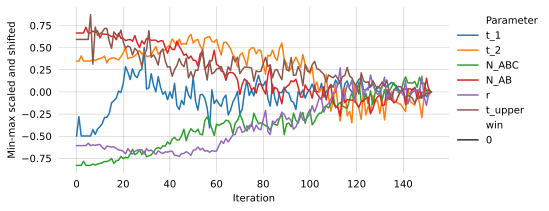

In [20]:
plot_convergence(analysis)

## Build species tree from analysis triplets

In [21]:
import ete3
from trio_tree import from_tuples, build_aho, node_map, preorder

trios = []
trio_estimates = []
for analysis in analyses:
    estimate_fits, param_map = read_estimates(analysis)
    estimate_fit = estimate_fits[0]
    estimates = estimate_fit['optimized_parameters']
    names = dict(zip(['A', 'B', 'C', 'D'], estimate_fit['settings']['species_list']))
    estimates['T_1'] = estimates['t_1']
    estimates['T_2'] = estimates['t_1'] + estimates['t_2']
    trio_estimates.append((estimates, names))
    trio = from_tuples(((names['A'], names['B']), names['C']))
    trios.append(trio)

merged_tree = build_aho(trios)
#show_tree(tree)

In [22]:
#s = str(tree.key)
import ete3
s = "(A:1,(B:1,(E:1,D:1):0.5):0.5);"
s = "(A,(B,(E:3,D:3):5):5);"
ete_tree = ete3.Tree(s, format=1, quoted_node_names=True)

In [25]:
from fill_ultrametric import fill_ultrametric_newick
s = fill_ultrametric_newick(s)
ete_tree = ete3.Tree(s, format=1, quoted_node_names=True)

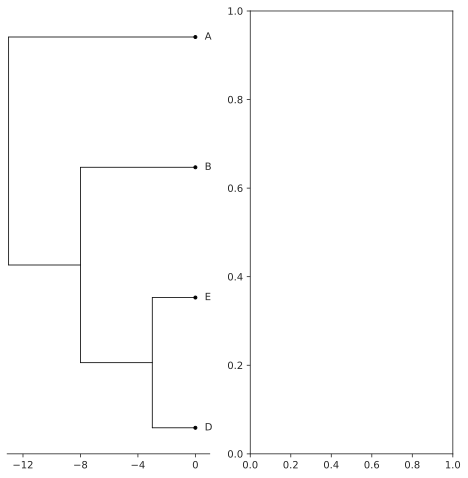

In [26]:
from plot_tree import plot_tree, make_comb_tree

with sns.axes_style('ticks'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8))
    leaf_info = plot_tree(ete_tree, ax1, margins=(0.2, 1, 0.2, 0.1), fontsize=10)

## Draw species tree with `demesdraw`

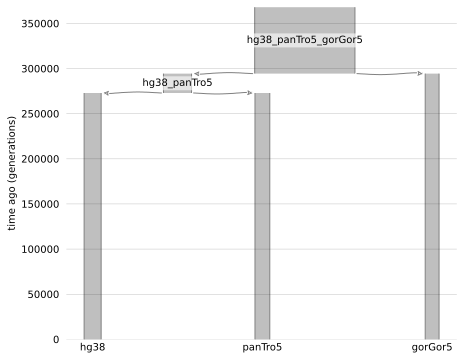

In [27]:
trio_nodes = [preorder(t) for t in trios]

external_branch_dummy_Ne = 10_000
estimate_mapping = {}
mapping = node_map(merged_tree, trios)

def name_string(n):
    if isinstance(n, str):
        return n
    return "_".join(map(str, flatten(n)))

populations = []
population_splits = []
for idx, node in enumerate(preorder(merged_tree)):

    for trio_idx, node_idx in mapping.get(idx, []):
        trio_node = trio_nodes[trio_idx][node_idx]
        if not isinstance(trio_node.key, str):
            nr_leaves = len(flatten(trio_node.key))
            sizes = []
            times = []
            assert nr_leaves <=3, trio_node.key
            N_var_name = f"N_{'ABC'[:nr_leaves]}"
            T_var_name = f'T_{nr_leaves-1}'
            sizes.append(trio_estimates[trio_idx][0][N_var_name])
            times.append(trio_estimates[trio_idx][0][T_var_name])
        else:
            sizes.append(external_branch_dummy_Ne)
    if node.left and node.right:
        population_splits.append(dict(ancestral=name_string(node.key), 
                                      derived=[name_string(node.left.key), name_string(node.right.key)], 
                                      time=sum(times)/len(times)))
    populations.append(dict(name=name_string(node.key), size=sum(sizes)/len(sizes)))

d = msprime.Demography()
for pop in populations:
    d.add_population(name=pop['name'], initial_size=pop['size'])
for event in population_splits:
    d.add_population_split(time=event['time'], derived=event['derived'], ancestral=event['ancestral'])
d.sort_events()
show_demography(d)

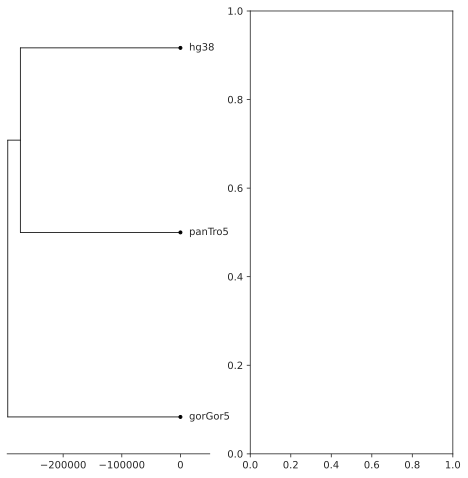

In [42]:
from demography_to_newick import demography_to_newick
newick = demography_to_newick(d.asdict(), internal_labels=True, fmt="%.10g")
demes_ete_tree = ete3.Tree(newick, format=1, quoted_node_names=True)
with sns.axes_style('ticks'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 8))
    leaf_info = plot_tree(demes_ete_tree, ax1, margins=(0.2, 50000, 0.2, 1000), fontsize=10)

## Viterbi decoding

How much of the alignment is assigned to each hidden state (a gene-tree topology
combined with coalescence-time intervals), and the state sequence along the
genome (windowed analyses, using `concat/{name}.viterbi.csv`) or along the
largest alignment block (unwindowed analyses):

In [4]:
analysis = analyses[0]

name = analysis.name
windowed = (analysis / 'concat' / f'{name}.viterbi.csv').exists()
if windowed:
    # concatenated per-window decode; block_start + block-local position
    # places each segment on the binning-reference genome
    vit = pd.read_csv(analysis / 'concat' / f'{name}.viterbi.csv')
    vit['genome_start'] = vit['block_start'] + vit['position_start']
    vit['genome_end'] = vit['block_start'] + vit['position_end']
    # under fit: genome every window has the same state legend
    states_file = sorted((analysis / 'viterbi').glob('*.hidden_states.csv'))[0]
else:
    vit = pd.read_csv(analysis / 'viterbi' / f'{name}.viterbi.csv')
    states_file = analysis / 'viterbi' / f'{name}.hidden_states.csv'
states = pd.read_csv(states_file)
labels = states.set_index('state_idx')['shorthand_name']
vit['length'] = vit['position_end'] - vit['position_start'] + 1

vit['most_likely_state'] = vit.most_likely_state.astype(int)
vit['most_likely_state'] = pd.Categorical(vit.most_likely_state, categories=states.index.values, ordered=True)

bp_per_state = (vit.groupby('most_likely_state', observed=False)['length'].sum()
                    .rename(index=labels)#.sort_values()
                    )

In [ ]:
states['a'], states['b'], states['c'] = zip(*states.shorthand_name.apply(eval))
states.head()


,state_idx,topology,interval_1st_coalescent,interval_2nd_coalescent,shorthand_name,a,b,c
0,0,"({sp1,sp2},sp3)",315157.64-357526.97,315157.64-357526.97,"(0, 0, 0)",0,0,0
1,1,"({sp1,sp2},sp3)",315157.64-357526.97,357526.97-429957.80,"(0, 0, 1)",0,0,1
2,2,"({sp1,sp2},sp3)",315157.64-357526.97,429957.80-inf,"(0, 0, 2)",0,0,2
3,3,"({sp1,sp2},sp3)",357526.97-429957.80,315157.64-357526.97,"(0, 1, 0)",0,1,0
4,4,"({sp1,sp2},sp3)",357526.97-429957.80,357526.97-429957.80,"(0, 1, 1)",0,1,1


In [6]:
vit.head()

,window,chrom,block_start,src_block,Block_idx,position_start,position_end,most_likely_state,genome_start,genome_end,length
0,w0000,hg38.chr1,0,0,0,0,10922,7,0,10922,10923
1,w0000,hg38.chr1,0,0,0,10923,17091,19,10923,17091,6169
2,w0000,hg38.chr1,0,0,0,17092,18289,23,17092,18289,1198
3,w0000,hg38.chr1,0,0,0,18290,49999,8,18290,49999,31710
4,w0000,hg38.chr1,50000,1,1,0,15396,10,50000,65396,15397


In [7]:
bp_per_state

most_likely_state
(0, 0, 0)     56413
(0, 0, 1)    119189
(0, 0, 2)    259670
(0, 1, 0)         0
(0, 1, 1)     56149
(0, 1, 2)     56562
(0, 2, 0)     11761
(0, 2, 1)     41856
(0, 2, 2)    272912
(1, 0, 0)         0
(1, 0, 1)     15397
(1, 0, 2)     50974
(1, 1, 1)         0
(1, 1, 2)         0
(1, 2, 2)      1378
(2, 0, 0)         0
(2, 0, 1)         0
(2, 0, 2)      4359
(2, 1, 1)         0
(2, 1, 2)     26088
(2, 2, 2)      3006
(3, 0, 0)         0
(3, 0, 1)         0
(3, 0, 2)     11331
(3, 1, 1)         0
(3, 1, 2)     12463
(3, 2, 2)       492
Name: length, dtype: int64

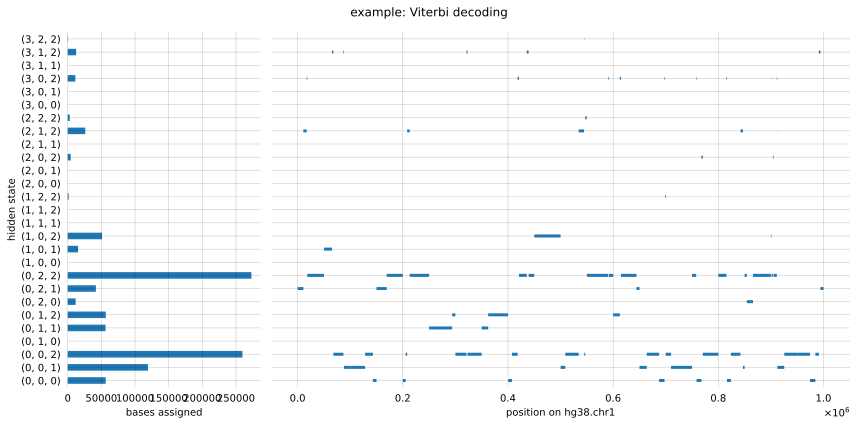

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, 
                             width_ratios=(1, 3))

bp_per_state.plot.barh(ax=axes[0], color='C0')
axes[0].set_xlabel('bases assigned')
axes[0].set_ylabel('hidden state')

if windowed:
    for seg in vit.itertuples():
        axes[1].hlines(seg.most_likely_state, seg.genome_start, seg.genome_end,
                        lw=3, color='C0')
    axes[1].set_xlabel(f"position on {vit['chrom'].iloc[0]}")
else:
    largest_block = vit.groupby('Block_idx')['length'].sum().idxmax()
    block = vit[vit['Block_idx'] == largest_block]
    for seg in block.itertuples():
        axes[1].hlines(seg.most_likely_state, seg.position_start, seg.position_end,
                        lw=3, color='C0')
    axes[1].set_xlabel(f'position in block {largest_block}')
axes[1].set_ylabel('state index')

fig.suptitle(f'{name}: Viterbi decoding')
fig.tight_layout()


## Posterior decoding

Posterior probability of every hidden state along the genome (windowed analyses,
using `concat/{name}.posterior.csv`) or along the largest alignment block
(unwindowed analyses). Positions are subsampled for plotting when the sequence
is long:

In [9]:
analysis = analyses[0]
name = analysis.name
windowed = (analysis / 'concat' / f'{name}.posterior.csv').exists()
if windowed:
    post = pd.read_csv(analysis / 'concat' / f'{name}.posterior.csv')
    prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
    post['genome_pos'] = post['block_start'] + post['position_idx']
    post = post.sort_values('genome_pos')
    probs = post[prob_cols].to_numpy().T
    xlabel = f"position on {post['chrom'].iloc[0]}"
else:
    post = pd.read_csv(analysis / 'posterior' / f'{name}.posterior.csv')
    prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
    block_col = post.columns[0]
    largest_block = post[block_col].value_counts().idxmax()
    probs = post[post[block_col] == largest_block][prob_cols].to_numpy().T
    xlabel = f'position in block {largest_block}'

In [10]:

def max_prob_segments(probs, collapse=False):

    if collapse:
        df = pd.DataFrame(probs)
        df['a'], df['b'], df['c']= zip(*states.shorthand_name.apply(eval))
        # df = df.loc[df.a > 1]
        df.set_index(['a', 'b', 'c'], inplace=True)
        df = df.groupby('a').agg('sum').T
        probs = df.to_numpy().T

    df = pd.DataFrame(dict(
        pos=np.arange(probs.shape[1]),
        prob=np.max(probs, axis=0),
        most_likely_state=np.argmax(probs, axis=0),
    ))
    df['_run'] = (df.most_likely_state != df.most_likely_state.shift()).cumsum()

    max_prob_segments = (
        df
        .groupby(['most_likely_state', '_run'])
#        .agg({'pos': ['min', 'max'], 'prob': 'mean'})
        .agg(genome_start=pd.NamedAgg(column="pos", aggfunc="min"),
             genome_end=pd.NamedAgg(column="pos", aggfunc="max"),
             mean_prob=pd.NamedAgg(column="prob", aggfunc="mean")
        )
        .reset_index()
        .drop(columns=['_run'])
    )
    # max_prob_segments.columns = max_prob_segments.columns.to_flat_index().map(lambda x: '_'.join(x))
    return max_prob_segments.sort_values('genome_start')#.rename(columns={'pos_min': 'start', 'pos_max': 'end'})

In [11]:
max_prob_segments(probs, collapse=False)

,most_likely_state,genome_start,genome_end,mean_prob
271,11,0,322,0.212630
314,13,323,611,0.178241
374,19,612,742,0.165325
315,13,743,755,0.150726
272,11,756,1015,0.177547
...,...,...,...,...
399,22,992493,993891,0.314063
427,23,993892,994156,0.407241
400,22,994157,994381,0.251929
270,10,994382,996371,0.195224


In [12]:
post_decoding = max_prob_segments(probs, collapse=True)
post_decoding

,most_likely_state,genome_start,genome_end,mean_prob
62,1,0,631,0.460841
85,2,632,731,0.368332
63,1,732,788,0.349207
0,0,789,10240,0.727682
86,2,10241,12359,0.547829
...,...,...,...,...
59,0,951679,980337,0.942180
124,2,980338,982746,0.522549
60,0,982747,991176,0.872005
170,3,991177,994312,0.760779


In [13]:
total_bp = post_decoding.groupby('most_likely_state').apply(lambda x: (x.genome_end - x.genome_start).sum()).to_frame('total_bp').reset_index()
total_bp['most_likely_state'] = total_bp.most_likely_state.astype('category')

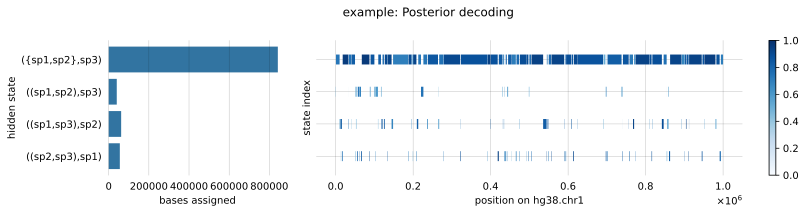

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True, 
                             width_ratios=(1, 3))

sns.barplot(total_bp, x='total_bp', y='most_likely_state', ax=axes[0])

axes[0].set_xlabel('bases assigned')
axes[0].set_ylabel('hidden state')
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(['({sp1,sp2},sp3)', '((sp1,sp2),sp3)', '((sp1,sp3),sp2)', '((sp2,sp3),sp1)'])

cmap = plt.get_cmap('Blues')
# if windowed:
for seg in post_decoding.itertuples():
    axes[1].hlines(seg.most_likely_state, seg.genome_start, seg.genome_end,
                    lw=10, color=cmap(seg.mean_prob))
axes[1].set_xlabel(f"position on {vit['chrom'].iloc[0]}")
# else:
#     largest_block = vit.groupby('Block_idx')['length'].sum().idxmax()
#     block = vit[vit['Block_idx'] == largest_block]
#     for seg in block.itertuples():
#         axes[1].hlines(seg.most_likely_state, seg.position_start, seg.position_end,
#                         lw=3, color='C0')
#     axes[1].set_xlabel(f'position in block {largest_block}')
axes[1].set_ylabel('state index')

norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap="RdBu", norm=norm)
sm.set_array([])

# Remove the legend and add a colorbar
#axes[1].get_legend().remove()
#axes[1].figure.colorbar(sm)

import matplotlib
fig.colorbar(matplotlib.colorizer.ColorizingArtist(matplotlib.colorizer.Colorizer(norm=norm, cmap=cmap)), ax=axes[1])

fig.suptitle(f'{name}: Posterior decoding')
fig.tight_layout()

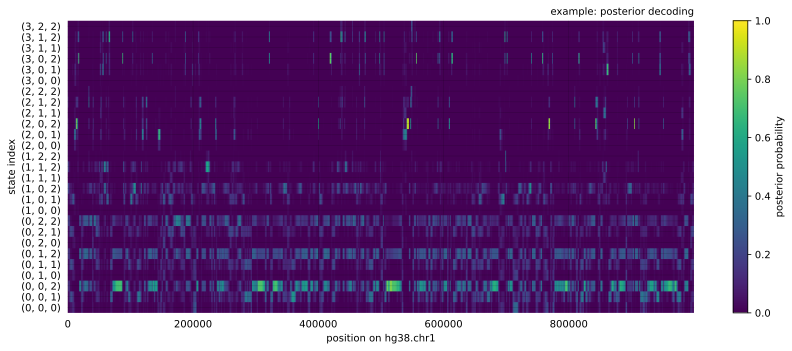

In [15]:

step = 1 #max(1, probs.shape[1] // 2000)
plt.figure(figsize=(12, 5))
plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
            cmap='viridis', vmin=0, vmax=1, 
            interpolation='nearest')
plt.colorbar(label='posterior probability')
plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
plt.yticks(states.state_idx, states.shorthand_name)
plt.ylabel('state index')
plt.title(f'{name}: posterior decoding')
plt.tight_layout()

In [30]:
df = pd.DataFrame(probs)
df['a'], df['b'], df['c']= zip(*states.shorthand_name.apply(eval))
# df = df.loc[df.a > 1]
df.set_index(['a', 'b', 'c'], inplace=True)
df = df.groupby('a').agg('sum').T
probs = df.to_numpy().T

<Axes: >

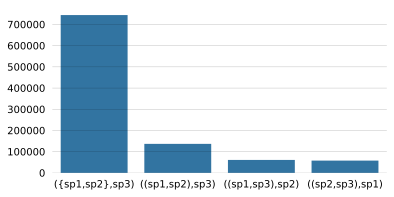

In [31]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(x=['({sp1,sp2},sp3)', '((sp1,sp2),sp3)', '((sp1,sp3),sp2)', '((sp2,sp3),sp1)'], y=np.sum(probs, axis=1), ax=ax)

Text(1.0, 1.0, 'example: posterior decoding')

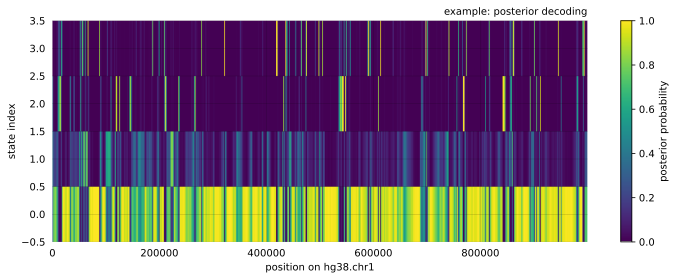

In [32]:
step = 1 #max(1, probs.shape[1] // 2000)
plt.figure(figsize=(12, 4))
plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
            cmap='viridis', vmin=0, vmax=1, 
            interpolation='nearest')
plt.colorbar(label='posterior probability')
plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
plt.ylabel('state index')
plt.title(f'{name}: posterior decoding')

Text(1.0, 1.0, 'example: posterior decoding')

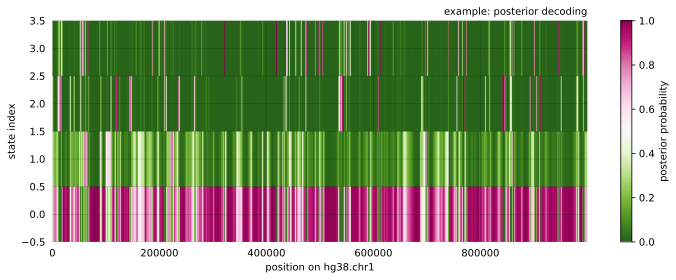

In [160]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

norm = colors.TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)


step = 1 #max(1, probs.shape[1] // 2000)
plt.figure(figsize=(12, 4))
plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
            cmap='PiYG_r', norm=norm,
            interpolation='nearest')
plt.colorbar(label='posterior probability')
plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
plt.ylabel('state index')
plt.title(f'{name}: posterior decoding')

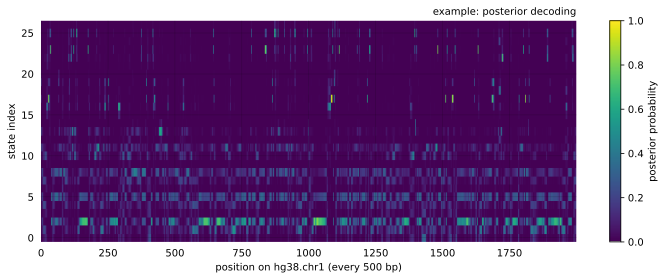

In [19]:
for analysis in analyses:
    name = analysis.name
    windowed = (analysis / 'concat' / f'{name}.posterior.csv').exists()
    if windowed:
        post = pd.read_csv(analysis / 'concat' / f'{name}.posterior.csv')
        prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
        post['genome_pos'] = post['block_start'] + post['position_idx']
        post = post.sort_values('genome_pos')
        probs = post[prob_cols].to_numpy().T
        xlabel = f"position on {post['chrom'].iloc[0]}"
    else:
        post = pd.read_csv(analysis / 'posterior' / f'{name}.posterior.csv')
        prob_cols = [c for c in post.columns if c.startswith('prob_state_')]
        block_col = post.columns[0]
        largest_block = post[block_col].value_counts().idxmax()
        probs = post[post[block_col] == largest_block][prob_cols].to_numpy().T
        xlabel = f'position in block {largest_block}'

    step = max(1, probs.shape[1] // 2000)
    plt.figure(figsize=(12, 4))
    plt.imshow(probs[:, ::step], aspect='auto', origin='lower',
               cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
    plt.colorbar(label='posterior probability')
    plt.xlabel(xlabel + (f' (every {step} bp)' if step > 1 else ''))
    plt.ylabel('state index')
    plt.title(f'{name}: posterior decoding')
    plt.show()